In [ ]:
import pandas as pd 
import os 
import numpy as np
import matplotlib.pyplot as plt
from pydmd import DMD
from itertools import product
from sklearn.metrics import mean_squared_error
import seaborn as sns

In [ ]:
def load_stacked_csvs(root_folder):
    """
    Walk through root_folder, read all CSVs inside each subfolder,
    and return a dict: {subfolder_name: stacked_dataframe}.
    """
    result = {}

    # Loop through items in the root folder
    for sub in os.listdir(root_folder):
        sub_path = os.path.join(root_folder, sub)

        # Only process directories
        if os.path.isdir(sub_path):
            csv_files = [
                os.path.join(sub_path, f)
                for f in os.listdir(sub_path)
                if f.lower().endswith(".csv")
            ]

            # Read and stack all CSVs in this subfolder
            dfs = []
            for csv in csv_files:
                df = pd.read_csv(csv)
                dfs.append(df)

            if dfs:
                stacked = pd.concat(dfs, ignore_index=True)
                result[sub] = stacked

    return result

In [ ]:
root = "C:\\Users\\natal\\DMD CU Quants\\data\\tidepool\\data_collector\\data"
data = load_stacked_csvs(root)


In [ ]:
data['EURQEUR']

,timestamp,price,volume,side,type
0,2025-03-02 03:11:11,0.999,45.67150,s,l
1,2025-03-02 10:00:32,0.999,45.67150,s,l
2,2025-03-02 19:32:05,1.001,52.94325,b,m
3,2025-03-02 19:54:31,0.999,52.94325,s,m
4,2025-03-02 20:46:20,1.001,469.84515,b,l
...,...,...,...,...,...
12077,2026-03-01 17:38:14,0.998,13.34000,s,l
12078,2026-03-02 00:34:17,0.998,5.30528,s,l
12079,2026-03-02 01:47:22,0.998,5.94057,s,l
12080,2026-03-02 02:08:36,0.998,5.94055,s,l


In [ ]:
def resample_all_to_hourly(data_dict):
    """
    Takes a dict of DataFrames (one per subfolder),
    sets Date as index, resamples, and returns a new dict.
    """
    out = {}

    for name, df in data_dict.items():
        # Ensure Date is datetime
        df['timestamp'] = pd.to_datetime(df['timestamp'])

        # Set index and resample
        hourly_df = (
            df.set_index('timestamp')
              .resample('d')   # change 'H' to 'm' or any freq you want
              .last()
              .reset_index()
        )

        out[name] = hourly_df

    return out

In [ ]:
data_hourly = resample_all_to_hourly(data)

In [ ]:
data_hourly['EURQEUR']

,timestamp,price,volume,side,type
0,2025-03-02,0.9990,337.66724,s,l
1,2025-03-03,0.9990,13.93100,s,l
2,2025-03-04,0.9989,497.87605,s,l
3,2025-03-05,0.9989,6.00000,s,l
4,2025-03-06,1.0010,60.30260,b,l
...,...,...,...,...,...
361,2026-02-26,0.9980,5.99009,s,l
362,2026-02-27,1.0089,14.44664,b,m
363,2026-02-28,0.9980,5.93377,s,l
364,2026-03-01,0.9980,13.34000,s,l


In [ ]:
data_daily['EURQEUR'][['timestamp','price']]

,timestamp,price
0,2025-03-02 03:00:00,0.999
1,2025-03-02 04:00:00,NaN
2,2025-03-02 05:00:00,NaN
3,2025-03-02 06:00:00,NaN
4,2025-03-02 07:00:00,NaN
...,...,...
8755,2026-03-01 22:00:00,NaN
8756,2026-03-01 23:00:00,NaN
8757,2026-03-02 00:00:00,0.998
8758,2026-03-02 01:00:00,0.998


In [ ]:
from functools import reduce

In [ ]:
def outer_join_prices(data_dict):
    """
    Takes a dict of DataFrames (data) and outer-joins them on 'timestamp',
    keeping only timestamp and price for each dataset.
    Each price column gets a suffix based on the dict key.
    """
    dfs = []

    for name, df in data_dict.items():
        temp = df.copy()

        # Ensure timestamp is datetime
        temp['timestamp'] = pd.to_datetime(temp['timestamp'])

        # Keep only timestamp + price
        temp = temp[['timestamp', 'price']]

        # Rename price column to include dataset name
        temp = temp.rename(columns={'price': f'price_{name}'})

        dfs.append(temp)

    # Outer join all DataFrames on timestamp
    merged = reduce(lambda left, right: pd.merge(left, right, on='timestamp', how='outer'), dfs)

    # Sort for cleanliness
    merged = merged.sort_values('timestamp').reset_index(drop=True)

    return merged

In [ ]:
final_df = outer_join_prices(data_daily)

In [ ]:
final_df.head(24)

,timestamp,price_EURQEUR,price_EURQUSD,price_EURREUR,price_EURRUSD,price_PAXGUSD,price_PYUSDEUR,price_USDREUR,price_USDRUSD,price_USDSUSD,price_XBTUSD
0,2025-03-01 21:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,86033.2
1,2025-03-01 22:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,86085.8
2,2025-03-01 23:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,86020.8
3,2025-03-02 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,85969.7
4,2025-03-02 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,86305.1
5,2025-03-02 02:00:00,NaN,NaN,NaN,1.0599,2854.17,NaN,NaN,NaN,NaN,85712.8
6,2025-03-02 03:00:00,0.999,1.0240,NaN,NaN,2852.87,NaN,NaN,NaN,NaN,85859.9
7,2025-03-02 04:00:00,NaN,NaN,NaN,NaN,2859.97,NaN,NaN,NaN,NaN,85685.8
8,2025-03-02 05:00:00,NaN,NaN,NaN,NaN,2857.81,NaN,NaN,NaN,NaN,85894.7
9,2025-03-02 06:00:00,NaN,NaN,NaN,NaN,2860.02,NaN,NaN,NaN,NaN,86250.1


In [ ]:
df_filled = final_df.ffill()
df_filled = df_filled.replace([np.inf, -np.inf], np.nan)
df_filled.dropna(inplace=True)

In [ ]:
df_filled.head(24)

,timestamp,price_EURQEUR,price_EURQUSD,price_EURREUR,price_EURRUSD,price_PAXGUSD,price_PYUSDEUR,price_USDREUR,price_USDRUSD,price_USDSUSD,price_XBTUSD
62,2025-03-04 11:00:00,0.9990,1.0280,0.9989,1.0492,2922.20,0.9506,0.9488,0.9988,1.3377,83918.2
63,2025-03-04 12:00:00,0.9990,1.0280,0.9989,1.0525,2924.04,0.9506,0.9486,0.9988,1.3377,83769.0
64,2025-03-04 13:00:00,0.9990,1.0536,0.9989,1.0525,2936.21,0.9506,0.9486,0.9988,1.3377,82699.9
65,2025-03-04 14:00:00,0.9990,1.0536,0.9989,1.0525,2916.11,0.9427,0.9486,0.9988,1.3377,83089.6
66,2025-03-04 15:00:00,0.9990,1.0536,0.9989,1.0525,2924.28,0.9427,0.9486,0.9988,1.3377,82899.9
67,2025-03-04 16:00:00,1.0010,1.0537,0.9989,1.0525,2927.91,0.9427,0.9486,0.9988,1.3377,83543.2
68,2025-03-04 17:00:00,1.0010,1.0537,0.9989,1.0525,2921.95,0.9427,0.9486,0.9988,1.3377,85369.8
69,2025-03-04 18:00:00,1.0010,1.0537,0.9989,1.0525,2925.30,0.9427,0.9486,0.9988,1.3377,86812.2
70,2025-03-04 19:00:00,1.0010,1.0537,0.9990,1.0525,2925.41,0.9427,0.9486,0.9988,1.3377,88179.4
71,2025-03-04 20:00:00,0.9990,1.0600,0.9989,1.0599,2931.34,0.9427,0.9486,0.9988,1.3377,86751.6


In [ ]:
def preprocess(df, asset_cols):
    prices = df[asset_cols].values
    logret = np.log(prices[1:] / prices[:-1])
    #make into new dataframe with same columns and date index
    logret_df = pd.DataFrame(logret, columns=asset_cols, index=df['timestamp'].iloc[1:])
    return logret_df

In [ ]:
preprocessed_df = preprocess(df_filled, asset_cols)
preprocessed_df.head()

,price_EURQEUR,price_EURQUSD,price_EURREUR,price_EURRUSD,price_PAXGUSD,price_PYUSDEUR,price_USDREUR,price_USDRUSD,price_USDSUSD,price_XBTUSD
timestamp,,,,,,,,,,
2025-03-04 12:00:00,0.000,0.000000,0.0,0.00314,0.000629,0.000000,-0.000211,0.0,0.0,-0.001780
2025-03-04 13:00:00,0.000,0.024598,0.0,0.00000,0.004153,0.000000,0.000000,0.0,0.0,-0.012845
2025-03-04 14:00:00,0.000,0.000000,0.0,0.00000,-0.006869,-0.008345,0.000000,0.0,0.0,0.004701
2025-03-04 15:00:00,0.000,0.000000,0.0,0.00000,0.002798,0.000000,0.000000,0.0,0.0,-0.002286
2025-03-04 16:00:00,0.002,0.000095,0.0,0.00000,0.001241,0.000000,0.000000,0.0,0.0,0.007730


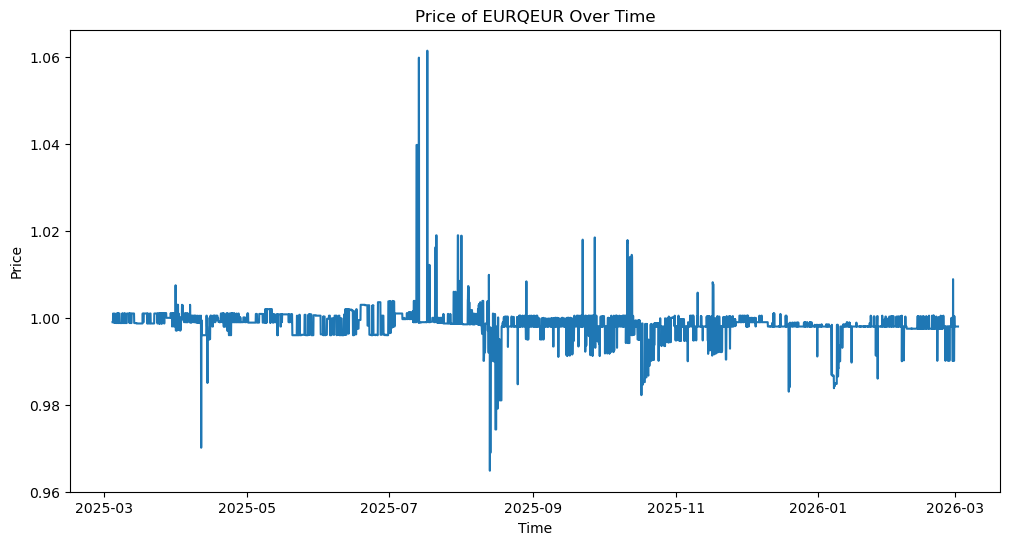

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df_filled['timestamp'], df_filled['price_EURQEUR'])
plt.title('Price of EURQEUR Over Time')
plt.xlabel('Time')
plt.ylabel('Price')
plt.show()

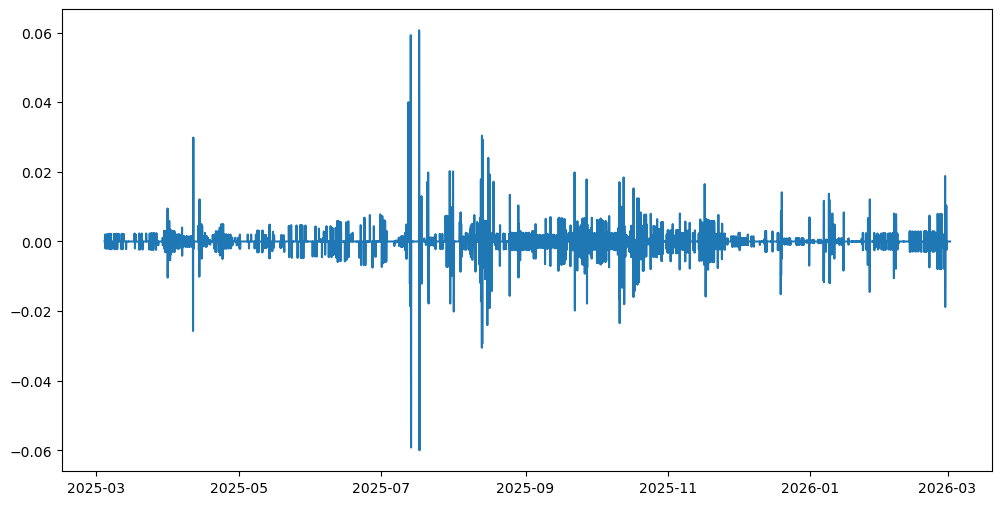

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(preprocessed_df.index, preprocessed_df['price_EURQEUR'])

In [ ]:
def dmd_forecast_multivariate(X_train, pred_steps):
    """
    X_train: array shape (n_assets, T) where T = input window length
    pred_steps: number of steps to forecast
    """
    dmd = DMD(svd_rank=3, tlsq_rank=5)
    dmd.fit(X_train)

    # Extend time horizon
    dmd.dmd_time['tend'] = X_train.shape[1] - 1 + pred_steps

    # Reconstructed data: shape (n_assets, T + pred_steps)
    rec = dmd.reconstructed_data.real

    # Extract only the future part
    return rec[:, -pred_steps:]

In [ ]:
def evaluate_multivariate_dmd(series_matrix, input_days, pred_days):
    """
    series_matrix: shape (n_assets, T_total)
    input_days: number of past days used for training
    pred_days: number of days ahead to forecast
    """
    n_assets, T = series_matrix.shape
    window = input_days + pred_days

    if T < window + 1:
        return np.inf

    errors = []

    for start in range(0, T - window + 1):
        end = start + window

        # Training window
        X_train = series_matrix[:, start:start + input_days]

        # True future
        X_true = series_matrix[:, start + input_days:end]

        # Forecast
        X_pred = dmd_forecast_multivariate(X_train, pred_days)

        # Joint MSE across all assets
        mse = mean_squared_error(X_true.flatten(), X_pred.flatten())
        errors.append(mse)

    return np.mean(errors)

In [ ]:
def grid_search_multivariate_dmd(df, asset_cols, input_days_grid, pred_days_grid):
    """
    df: hourly dataframe
    asset_cols: list of 5 asset columns
    """
    # Convert to matrix shape (n_assets, T)
    series_matrix = df[asset_cols].T.values

    results = []

    for input_days, pred_days in product(input_days_grid, pred_days_grid):
        mse = evaluate_multivariate_dmd(series_matrix, input_days, pred_days)
        results.append({
            "input_days": input_days,
            "pred_days": pred_days,
            "mse": mse
        })
        print(f"input={input_days}, pred={pred_days}, MSE={mse:.6f}")

    return pd.DataFrame(results)

In [ ]:
def plot_heatmap(results_df, title="Multivariate DMD Forecasting Error"):
    pivot = results_df.pivot(index="input_days", columns="pred_days", values="mse")

    plt.figure(figsize=(10, 6))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".4f",
        cmap="viridis_r",
        cbar_kws={"label": "MSE"}
    )
    plt.title(title)
    plt.xlabel("Prediction Horizon (days ahead)")
    plt.ylabel("Input Window (days)")
    plt.tight_layout()
    plt.show()

In [ ]:
asset_cols = [
    "price_EURQEUR", 
    "price_EURQUSD", 
    "price_EURREUR", 
    "price_EURRUSD", 
    "price_PAXGUSD", 
    "price_PYUSDEUR", 
    "price_USDREUR", 
    "price_USDRUSD", 
    "price_USDSUSD", 
    "price_XBTUSD"
]

# Example grids (in days)
input_grid = [5,6,7,8,9]
pred_grid = [1, 2, 3,4,5,6,7,8,9]

results_df = grid_search_multivariate_dmd(
    df_filled,
    asset_cols,
    input_grid,
    pred_grid
)

C:\Users\natal\anaconda3\Lib\site-packages\pydmd\snapshots.py:73: UserWarning: Input data condition number 78852239.44332036. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
C:\Users\natal\anaconda3\Lib\site-packages\pydmd\snapshots.py:73: UserWarning: Input data condition number 77632940.8692424. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
C:\Users\natal\anaconda3\Lib\site-packages\pydmd\snapshots.py:73: UserWarning: Input data condition number 245177636.38070756. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
C:\Users\natal\anaconda3\Lib\site-packages\pydmd\snapshots.py:73: UserWarning: Input data condition number 7.898490242826452e+17. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
C:\Users\natal\anaconda3\Lib\site-packages\pydmd\snapshots.py:73

LinAlgError: Array must not contain infs or NaNs